In [1]:
pip install torch torchvision torchaudio

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms


In [3]:
train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data', train=True, download=True,
     transform=transforms.ToTensor()),
    batch_size=64, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 56.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.35MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.65MB/s]


In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10))

    def forward(self, x):
     return self.layers(x)

model = MLP()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())



In [5]:
num_epochs = 5
for epoch in range(num_epochs):
 for images, labels in train_loader:
    outputs = model(images)
    loss = loss_fn(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    break


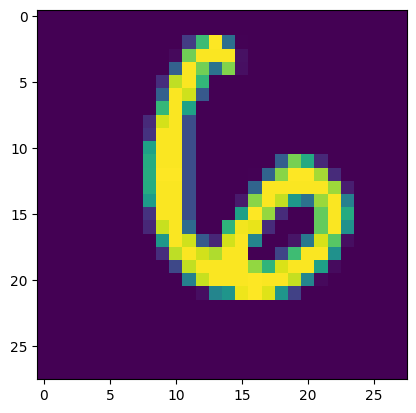

الحقيقة: 6
تنبؤ النموذج: 6


In [6]:
import matplotlib.pyplot as plt

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True)

image, label = test_dataset[88]

plt.imshow(image)
plt.show()

print(f"الحقيقة: {label}")

image_tensor = torchvision.transforms.ToTensor()(image)

model.eval()
with torch.no_grad():
    output = model(image_tensor)
    predicted = torch.argmax(output, dim=1).item()

print(f"تنبؤ النموذج: {predicted}")